In [1]:
import os

project_dir = '/blue/shenhaowang/qingqisong/be-and-active-travel'
os.chdir(project_dir)

In [2]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device: {torch.cuda.get_device_name(0)}")

# Check if torch.amp has the required functions
try:
    from torch.amp import custom_fwd, custom_bwd
    print("✓ torch.amp.custom_fwd available")
except ImportError as e:
    print(f"✗ torch.amp functions not available: {e}")

PyTorch version: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
Device: NVIDIA L4
✓ torch.amp.custom_fwd available


In [2]:
import os
import sys



project_dir = '/blue/shenhaowang/qingqisong/be-and-active-travel'
os.chdir(project_dir)

# ============================================================================
# IMPORTS
# ============================================================================

import torch
print(f"PyTorch version: {torch.__version__}")

import torch.utils._pytree
if not hasattr(torch.utils._pytree, 'register_pytree_node'):
    torch.utils._pytree.register_pytree_node = lambda *args, **kwargs: None

import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import statsmodels.api as sm

try:
    import open_clip
    has_open_clip = True
    print("✓ open_clip")
except:
    has_open_clip = False
    print("✗ open_clip")

try:
    from huggingface_hub import hf_hub_download
    has_hf_hub = True
    print("✓ huggingface_hub")
except:
    has_hf_hub = False
    print("✗ huggingface_hub")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\nDevice: {device}")

# ============================================================================
# CONFIG - WITH LOCAL DINOV3 WEIGHTS
# ============================================================================

class Config:
    DATA_DIR = Path('./')
    TRIP_FILE = DATA_DIR / 'chicago_trip_level_with_embeddings.csv'
    ADAPTIVE_DIR = DATA_DIR / 'satellite_images_adaptive1'
    
    # Local DINOv3 SAT weights (UPDATE THESE PATHS!)
    DINOV3_VITL16_WEIGHTS = DATA_DIR / 'dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth'
    DINOV3_VIT7B16_WEIGHTS = DATA_DIR / 'dinov3_vit7b16_pretrain_sat493m.pth'  # If you have it
    
    # Base models
    FOUNDATION_MODELS = [
        'clip_vitb32',
        'clip_vitl14',
        'remoteclip_rn50',
        'remoteclip_vitb32',
        'remoteclip_vitl14',
        'dinov2_small',
        'dinov2_base',
    ]
    
    # Add DINOv3 SAT if weights exist
    if DINOV3_VITL16_WEIGHTS.exists():
        FOUNDATION_MODELS.append('dinov3_sat_vitl16')
        print(f"✓ Found DINOv3 ViT-L/16 weights: {DINOV3_VITL16_WEIGHTS}")
    else:
        print(f"✗ DINOv3 ViT-L/16 weights not found at: {DINOV3_VITL16_WEIGHTS}")
    
    if DINOV3_VIT7B16_WEIGHTS.exists():
        FOUNDATION_MODELS.append('dinov3_sat_vit7b16')
        print(f"✓ Found DINOv3 ViT-7B/16 weights: {DINOV3_VIT7B16_WEIGHTS}")
    else:
        print(f"ℹ DINOv3 ViT-7B/16 weights not found (optional)")

    PCA_COMPONENTS = 100
    LASSO_C = 0.02
    TEST_SIZE = 0.2
    RANDOM_STATE = 42
    OUTPUT_DIR = DATA_DIR / 'final_foundation_analysis_output2'
    OUTPUT_DIR.mkdir(exist_ok=True)

config = Config()

print(f"\nModels ({len(config.FOUNDATION_MODELS)}):")
for m in config.FOUNDATION_MODELS:
    print(f"  • {m}")

def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    return ''

# ============================================================================
# DATA LOADING
# ============================================================================

print(f"\n{'='*80}")
print("LOADING DATA")
print(f"{'='*80}")

def parse_adaptive_index(image_dir):
    image_dir = Path(image_dir)
    records = []
    for fpath in image_dir.glob('*.png'):
        parts = fpath.stem.split('_')
        try:
            if not parts[0].startswith('point'):
                continue
            point_id = int(parts[0].replace('point', ''))
            if len(parts) >= 4 and parts[1].startswith('tract'):
                tract_id, lat, lon = parts[1].replace('tract', ''), float(parts[2]), float(parts[3])
            else:
                tract_id, lat, lon = None, float(parts[1]), float(parts[2])
            records.append({
                'point_id': point_id,
                'tract_id': tract_id,
                'lat': lat,
                'lon': lon,
                'satellite_image_path': str(fpath)
            })
        except (ValueError, IndexError):
            continue
    return pd.DataFrame(records).sort_values('point_id').reset_index(drop=True)

emb_index = parse_adaptive_index(config.ADAPTIVE_DIR)
print(f"Images: {len(emb_index)}")

trip_df = pd.read_csv(config.TRIP_FILE)
print(f"Trips: {len(trip_df):,}")

person_hh = [c for c in [
    'age', 'Female', 'License', 'Employed', 'Student',
    'White', 'Black', 'Asian', 'Hispanic', 'Bachelor_Above',
    'hhveh', 'Zero_Vehicle_HH', 'hhsize', 'Low_Income', 'High_Income', 'Home_Owner'
] if c in trip_df.columns]

trip_f = [c for c in ['od_dist_mi'] if c in trip_df.columns]
orig_be = [c for c in trip_df.columns if c.startswith('O_') and '_pc' not in c and trip_df[c].notna().mean() > 0.5]
dest_be = [c for c in trip_df.columns if c.startswith('D_') and '_pc' not in c and trip_df[c].notna().mean() > 0.5]
tabular_feats = person_hh + trip_f + orig_be + dest_be

required_cols = tabular_feats + ['is_transit', 'orig_lat', 'orig_lon', 'dest_lat', 'dest_lon']
df = trip_df.dropna(subset=required_cols).copy()
for col in person_hh + trip_f:
    if col in df.columns:
        df = df[df[col] >= 0]

print(f"Clean: {len(df):,}, transit: {df['is_transit'].mean()*100:.1f}%")

coord_to_idx = {(round(r['lat'], 6), round(r['lon'], 6)): i for i, r in emb_index.iterrows()}

df['orig_emb_idx'] = df.apply(lambda r: coord_to_idx.get((round(r['orig_lat'], 6), round(r['orig_lon'], 6)), -1), axis=1)
df['dest_emb_idx'] = df.apply(lambda r: coord_to_idx.get((round(r['dest_lat'], 6), round(r['dest_lon'], 6)), -1), axis=1)
df = df[(df['orig_emb_idx'] >= 0) & (df['dest_emb_idx'] >= 0)].copy()

orig_idx = df['orig_emb_idx'].values.astype(int)
dest_idx = df['dest_emb_idx'].values.astype(int)
y_all = df['is_transit'].values
X_tab_raw = df[tabular_feats].values

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=config.TEST_SIZE,
    stratify=y_all,
    random_state=config.RANDOM_STATE
)

y_train, y_test = y_all[train_idx], y_all[test_idx]

scaler_tab = StandardScaler()
X_tab_train = scaler_tab.fit_transform(X_tab_raw[train_idx])
X_tab_test = scaler_tab.transform(X_tab_raw[test_idx])

print(f"Train: {len(train_idx):,}, Test: {len(test_idx):,}")

# ============================================================================
# DATASET
# ============================================================================

class SatelliteDataset(Dataset):
    def __init__(self, index_df, transform=None, resize_size=224):
        self.index_df = index_df.reset_index(drop=True)
        self.resize_size = resize_size
        self.transform = transform or transforms.Compose([
            transforms.Resize((resize_size, resize_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.index_df)
    
    def __getitem__(self, idx):
        from PIL import Image
        row = self.index_df.iloc[idx]
        img_path = Path(row['satellite_image_path'])
        
        if img_path.exists():
            img = self.transform(Image.open(img_path).convert('RGB'))
        else:
            img = torch.zeros(3, self.resize_size, self.resize_size)
        
        return {
            'image': img,
            'lat': torch.tensor(row['lat'], dtype=torch.float32),
            'lon': torch.tensor(row['lon'], dtype=torch.float32),
            'point_id': row['point_id']
        }

# ============================================================================
# HELPER: Load DINOv3 with local weights
# ============================================================================

def load_dinov3_local(model_type='vitl16', weights_path=None, device='cuda'):
    """
    Load DINOv3 model with local weights, bypassing PyTorch Hub download.
    
    Args:
        model_type: 'vitl16' or 'vit7b16'
        weights_path: Path to local .pth file
        device: 'cuda' or 'cpu'
    """
    # Load model architecture via PyTorch Hub (without pretrained weights)
    model = torch.hub.load(
        'facebookresearch/dinov3',
        f'dinov3_{model_type}',
        pretrained=False,  # Don't download weights
        source='github',
        verbose=False
    )
    
    # Load local weights
    print(f"    Loading weights from: {weights_path}")
    state_dict = torch.load(weights_path, map_location='cpu')
    
    # Handle different state_dict formats
    if 'model' in state_dict:
        state_dict = state_dict['model']
    elif 'state_dict' in state_dict:
        state_dict = state_dict['state_dict']
    
    # Remove 'module.' prefix if present (from DataParallel)
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    
    # Load weights
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    
    if missing:
        print(f"    Warning: Missing keys: {len(missing)}")
    if unexpected:
        print(f"    Warning: Unexpected keys: {len(unexpected)}")
    
    model = model.to(device).eval()
    return model

# ============================================================================
# EXTRACTOR WITH LOCAL DINOV3
# ============================================================================

class SatelliteEmbeddingExtractor:
    def __init__(self, model_name, device='cuda'):
        self.model_name = model_name
        self.device = device
        self.model = None
        self.transform = None
        self.embed_dim = None
        self._is_clip = False
        self._is_dinov3 = False
        self._resize_size = 224
        self._load()
    
    def _load(self):
        name = self.model_name
        print(f"\n  Loading [{name}]...")
        
        if name == 'clip_vitb32':
            import open_clip
            m, _, prep = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
            self.model, self.transform, self.embed_dim, self._is_clip = m.to(self.device).eval(), prep, 512, True
            print("    ✓ CLIP ViT-B/32 (512-d)")
        
        elif name == 'clip_vitl14':
            import open_clip
            m, _, prep = open_clip.create_model_and_transforms('ViT-L-14', pretrained='openai')
            self.model, self.transform, self.embed_dim, self._is_clip = m.to(self.device).eval(), prep, 768, True
            print("    ✓ CLIP ViT-L/14 (768-d)")
        
        elif name.startswith('remoteclip_'):
            import open_clip
            arch_map = {
                'remoteclip_rn50': ('RN50', 1024),
                'remoteclip_vitb32': ('ViT-B-32', 512),
                'remoteclip_vitl14': ('ViT-L-14', 768)
            }
            arch, dim = arch_map[name]
            ckpt = hf_hub_download(
                "chendelong/RemoteCLIP",
                f"RemoteCLIP-{arch}.pt",
                cache_dir=str(config.DATA_DIR / 'checkpoints')
            )
            m, _, prep = open_clip.create_model_and_transforms(arch)
            m.load_state_dict(torch.load(ckpt, map_location="cpu"))
            self.model, self.transform, self.embed_dim, self._is_clip = m.to(self.device).eval(), prep, dim, True
            print(f"    ✓ RemoteCLIP-{arch} ({dim}-d)")
        
        elif name == 'dinov2_small':
            self.model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False).to(self.device).eval()
            self.embed_dim = 384
            print("    ✓ DINOv2-Small (384-d)")
        
        elif name == 'dinov2_base':
            self.model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', verbose=False).to(self.device).eval()
            self.embed_dim = 768
            print("    ✓ DINOv2-Base (768-d)")
        
        # ====================================================================
        # DINOv3 SAT with LOCAL weights
        # ====================================================================
        elif name == 'dinov3_sat_vitl16':
            print("    Loading DINOv3 ViT-L/16 SAT with local weights...")
            
            self.model = load_dinov3_local(
                model_type='vitl16',
                weights_path=config.DINOV3_VITL16_WEIGHTS,
                device=self.device
            )
            
            # Satellite imagery transform
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=(0.430, 0.411, 0.296),
                    std=(0.213, 0.156, 0.143)
                )
            ])
            
            self.embed_dim = 1024
            self._is_dinov3 = True
            print(f"    ✓ DINOv3 ViT-L/16 SAT ({self.embed_dim}-d)")
        
        elif name == 'dinov3_sat_vit7b16':
            print("    Loading DINOv3 ViT-7B/16 SAT with local weights...")
            print("    (This is VERY large ~25GB)")
            
            self.model = load_dinov3_local(
                model_type='vit7b16',
                weights_path=config.DINOV3_VIT7B16_WEIGHTS,
                device=self.device
            )
            
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=(0.430, 0.411, 0.296),
                    std=(0.213, 0.156, 0.143)
                )
            ])
            
            self.embed_dim = 6144
            self._is_dinov3 = True
            print(f"    ✓ DINOv3 ViT-7B/16 SAT ({self.embed_dim}-d)")
        
        else:
            raise ValueError(f"Unknown model: {name}")
    
    @torch.no_grad()
    def extract(self, index_df, batch_size=32):
        # Smaller batch for large models
        if 'vit7b' in self.model_name:
            batch_size = 1
            print(f"    Using batch_size=1 for 7B model")
        elif 'dinov3' in self.model_name:
            batch_size = 8
        
        dataset = SatelliteDataset(index_df, self.transform, self._resize_size)
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=(self.device == 'cuda')
        )
        
        all_emb, all_lat, all_lon, all_pid = [], [], [], []
        
        for batch_idx, batch in enumerate(loader):
            if batch_idx % 50 == 0 and batch_idx > 0:
                print(f"    Processed {batch_idx}/{len(loader)} batches...")
            
            imgs = batch['image'].to(self.device).float()
            
            if self._is_clip:
                emb = self.model.encode_image(imgs)
                emb = emb / emb.norm(dim=-1, keepdim=True)
            
            elif 'dinov2' in self.model_name or self._is_dinov3:
                # Both DINOv2 and DINOv3 use same interface
                emb = self.model(imgs)
            
            else:
                raise ValueError(f"Unknown forward pass for {self.model_name}")
            
            if emb.dim() > 2:
                emb = emb.flatten(1)
            
            all_emb.append(emb.cpu().float().numpy())
            all_lat.extend(batch['lat'].tolist())
            all_lon.extend(batch['lon'].tolist())
            all_pid.extend(batch['point_id'].tolist())
        
        return {
            'embeddings': np.vstack(all_emb),
            'lats': np.array(all_lat),
            'lons': np.array(all_lon),
            'point_ids': np.array(all_pid)
        }

# ============================================================================
# EXTRACTION
# ============================================================================

print(f"\n{'='*80}")
print("EXTRACTING EMBEDDINGS")
print(f"{'='*80}")

embeddings_dict = {}

for model_name in config.FOUNDATION_MODELS:
    save_path = config.OUTPUT_DIR / f'embeddings_{model_name}.npy'
    
    if save_path.exists():
        print(f"\n✓ Loading cached: {model_name}")
        emb = np.load(save_path)
        embeddings_dict[model_name] = {
            'embeddings': emb,
            'embed_dim': emb.shape[1],
            'lats': emb_index['lat'].values,
            'lons': emb_index['lon'].values,
            'point_ids': emb_index['point_id'].values
        }
        print(f"  Shape: {emb.shape}")
        continue
    
    try:
        extractor = SatelliteEmbeddingExtractor(model_name, device)
        result = extractor.extract(emb_index)
        
        embeddings_dict[model_name] = {
            'embeddings': result['embeddings'],
            'embed_dim': extractor.embed_dim,
            'lats': result['lats'],
            'lons': result['lons'],
            'point_ids': result['point_ids']
        }
        
        np.save(save_path, result['embeddings'])
        print(f"  ✓ Saved: {save_path}")
        print(f"  Shape: {result['embeddings'].shape}")
        
        # Free memory for large models
        if 'vit7b' in model_name:
            del extractor.model
            torch.cuda.empty_cache()
            print("  ✓ Freed GPU memory")
    
    except Exception as e:
        print(f"  ✗ Failed: {model_name}")
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print(f"Successfully loaded {len(embeddings_dict)} models:")
for name, data in embeddings_dict.items():
    print(f"  • {name:<30} {data['embeddings'].shape}")
print(f"{'='*80}")

# ============================================================================
# PCA & POST-LASSO (Same as before - add the code here)
# ============================================================================

def create_model_pca_features(embeddings, n_components, train_idx, test_idx, orig_idx, dest_idx):
    emb_o_train = embeddings[orig_idx[train_idx]]
    emb_d_train = embeddings[dest_idx[train_idx]]
    emb_o_test = embeddings[orig_idx[test_idx]]
    emb_d_test = embeddings[dest_idx[test_idx]]
    
    all_train = np.vstack([emb_o_train, emb_d_train])
    
    scaler = StandardScaler()
    all_train_scaled = scaler.fit_transform(all_train)
    
    max_comp = min(n_components, all_train_scaled.shape[0], all_train_scaled.shape[1])
    
    pca = PCA(n_components=max_comp, random_state=config.RANDOM_STATE)
    pca.fit(all_train_scaled)
    
    var_explained = pca.explained_variance_ratio_.sum() * 100
    
    o_train_pca = pca.transform(scaler.transform(emb_o_train))
    o_test_pca = pca.transform(scaler.transform(emb_o_test))
    d_train_pca = pca.transform(scaler.transform(emb_d_train))
    d_test_pca = pca.transform(scaler.transform(emb_d_test))
    
    X_train_pca = np.column_stack([o_train_pca, d_train_pca])
    X_test_pca = np.column_stack([o_test_pca, d_test_pca])
    
    return X_train_pca, X_test_pca, var_explained, max_comp, pca, scaler

PyTorch version: 2.7.1+cu128
✓ open_clip
✓ huggingface_hub

Device: cuda
✓ Found DINOv3 ViT-L/16 weights: dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth
ℹ DINOv3 ViT-7B/16 weights not found (optional)

Models (8):
  • clip_vitb32
  • clip_vitl14
  • remoteclip_rn50
  • remoteclip_vitb32
  • remoteclip_vitl14
  • dinov2_small
  • dinov2_base
  • dinov3_sat_vitl16

LOADING DATA
Images: 1148
Trips: 20,815
Clean: 13,015, transit: 17.9%
Train: 10,412, Test: 2,603

EXTRACTING EMBEDDINGS

✓ Loading cached: clip_vitb32
  Shape: (1148, 512)

✓ Loading cached: clip_vitl14
  Shape: (1148, 768)

✓ Loading cached: remoteclip_rn50
  Shape: (1148, 1024)

✓ Loading cached: remoteclip_vitb32
  Shape: (1148, 512)

✓ Loading cached: remoteclip_vitl14
  Shape: (1148, 768)

✓ Loading cached: dinov2_small
  Shape: (1148, 384)

✓ Loading cached: dinov2_base
  Shape: (1148, 768)

✓ Loading cached: dinov3_sat_vitl16
  Shape: (1148, 1024)

Successfully loaded 8 models:
  • clip_vitb32                    (1148, 512

In [3]:
# ============================================================================
# POST-LASSO ANALYSIS
# ============================================================================

print(f"\n{'='*80}")
print("POST-LASSO ANALYSIS")
print(f"{'='*80}")

postlasso_results = {}

for model_name, model_data in embeddings_dict.items():
    print(f"\n{'='*80}")
    print(f"POST-LASSO: {model_name.upper()}")
    print(f"{'='*80}")
    
    embeddings = model_data['embeddings']
    embed_dim = model_data['embed_dim']
    
    print(f"  Original embedding dim: {embed_dim}")
    
    print(f"\n  [1] Creating PCA features...")
    X_tr_img, X_te_img, var_exp, n_comp, pca_obj, scaler_obj = create_model_pca_features(
        embeddings, config.PCA_COMPONENTS, train_idx, test_idx, orig_idx, dest_idx
    )
    
    print(f"    PCA components: {n_comp}")
    print(f"    Variance explained: {var_exp:.2f}%")
    
    X_tr_full = np.column_stack([X_tab_train, X_tr_img])
    X_te_full = np.column_stack([X_tab_test, X_te_img])
    
    scaler_full = StandardScaler()
    X_tr_scaled = scaler_full.fit_transform(X_tr_full)
    X_te_scaled = scaler_full.transform(X_te_full)
    
    img_feat_names = (
        [f'O_{model_name}_pc{i+1}' for i in range(n_comp)] +
        [f'D_{model_name}_pc{i+1}' for i in range(n_comp)]
    )
    all_feat_names = tabular_feats + img_feat_names
    
    print(f"\n  [2] Lasso variable selection (C={config.LASSO_C})...")
    lasso = LogisticRegression(
        penalty='l1', C=config.LASSO_C, solver='liblinear',
        max_iter=3000, random_state=config.RANDOM_STATE
    )
    lasso.fit(X_tr_scaled, y_train)
    
    coefs = lasso.coef_[0]
    selected_mask = coefs != 0
    n_selected = selected_mask.sum()
    
    n_tab_selected = sum(1 for i, name in enumerate(all_feat_names)
                         if selected_mask[i] and name in tabular_feats)
    n_img_selected = sum(1 for i, name in enumerate(all_feat_names)
                         if selected_mask[i] and model_name in name)
    
    print(f"    Variables selected: {n_selected}")
    print(f"      Tabular: {n_tab_selected}")
    print(f"      Image: {n_img_selected}")
    
    if n_selected == 0:
        print(f"    ⚠️ No variables selected, skipping")
        continue
    
    print(f"\n  [3] Post-Lasso estimation...")
    selected_indices = np.where(selected_mask)[0]
    selected_names = [all_feat_names[i] for i in selected_indices]
    
    X_tr_selected = X_tr_scaled[:, selected_indices]
    X_te_selected = X_te_scaled[:, selected_indices]
    
    X_tr_sm = sm.add_constant(X_tr_selected, has_constant='add')
    X_te_sm = sm.add_constant(X_te_selected, has_constant='add')
    
    try:
        logit = sm.Logit(y_train, X_tr_sm)
        result = logit.fit(disp=0, maxiter=1000, method='lbfgs')
        
        coef_data = []
        for i, name in enumerate(selected_names):
            idx = i + 1
            
            if name in tabular_feats:
                if name in person_hh:
                    cat = 'Person/HH'
                elif name in trip_f:
                    cat = 'Trip'
                elif name in orig_be or name in dest_be:
                    cat = 'Zone BE'
                else:
                    cat = 'Tabular'
            else:
                cat = model_name
            
            coef_data.append({
                'variable': name,
                'coef': result.params[idx],
                'std_err': result.bse[idx],
                'z': result.tvalues[idx],
                'p_value': result.pvalues[idx],
                'category': cat
            })
        
        coef_df = pd.DataFrame(coef_data)
        coef_df['abs_coef'] = np.abs(coef_df['coef'])
        coef_df['sig'] = coef_df['p_value'].apply(sig_stars)
        
        img_df = coef_df[coef_df['category'] == model_name]
        sig_img = img_df[img_df['p_value'] < 0.05]
        
        print(f"    Image features significant (p<0.05): {len(sig_img)} / {len(img_df)}")
        
        ll_train = result.llf
        ll_null_train = result.llnull
        pseudo_r2_train = result.prsquared
        aic = result.aic
        bic = result.bic
        
        y_prob_test = result.predict(X_te_sm)
        auc_test = roc_auc_score(y_test, y_prob_test)
        acc_test = accuracy_score(y_test, (y_prob_test > 0.5).astype(int))
        
        eps = 1e-15
        y_prob_clipped = np.clip(y_prob_test, eps, 1 - eps)
        ll_test = np.sum(y_test * np.log(y_prob_clipped) + (1 - y_test) * np.log(1 - y_prob_clipped))
        
        p_null = y_train.mean()
        ll_null_test = np.sum(y_test * np.log(p_null) + (1 - y_test) * np.log(1 - p_null))
        pseudo_r2_test = 1 - (ll_test / ll_null_test)
        
        print(f"    Pseudo R² (train): {pseudo_r2_train:.4f}")
        print(f"    Pseudo R² (test):  {pseudo_r2_test:.4f}")
        print(f"    AUC (test): {auc_test:.4f}")
        
        postlasso_results[model_name] = {
            'model_name': model_name,
            'embed_dim': embed_dim,
            'pca_components': n_comp,
            'variance_explained': var_exp,
            'n_selected': n_selected,
            'n_tab_selected': n_tab_selected,
            'n_img_selected': n_img_selected,
            'n_img_significant': len(sig_img),
            'll_train': ll_train,
            'll_test': ll_test,
            'pseudo_r2_train': pseudo_r2_train,
            'pseudo_r2_test': pseudo_r2_test,
            'aic': aic,
            'bic': bic,
            'auc_test': auc_test,
            'acc_test': acc_test,
            'coef_df': coef_df,
            'sig_img_features': sig_img,
            'statsmodels_result': result,
            'pca': pca_obj,
            'scaler': scaler_obj,
            'selected_names': selected_names
        }
        
        print(f"    ✓ Analysis complete")
    
    except Exception as e:
        print(f"    ✗ Error in fitting: {e}")

print(f"\n{'='*80}")
print(f"POST-LASSO COMPLETE: {len(postlasso_results)} models analyzed")
print(f"{'='*80}")

# ============================================================================
# CROSS-MODEL COMPARISON
# ============================================================================

if len(postlasso_results) > 0:
    print(f"\n{'='*80}")
    print("CROSS-MODEL COMPARISON")
    print(f"{'='*80}")
    
    comparison_data = []
    for model_name, res in postlasso_results.items():
        comparison_data.append({
            'Model': model_name,
            'Embed Dim': res['embed_dim'],
            'PCA Comps': res['pca_components'],
            'Var Exp %': f"{res['variance_explained']:.1f}",
            'Total Sel': res['n_selected'],
            'Tab Sel': res['n_tab_selected'],
            'Img Sel': res['n_img_selected'],
            'Img Sig': res['n_img_significant'],
            'ρ² (train)': f"{res['pseudo_r2_train']:.4f}",
            'ρ² (test)': f"{res['pseudo_r2_test']:.4f}",
            'AUC (test)': f"{res['auc_test']:.4f}",
            'AIC': f"{res['aic']:.1f}",
            'BIC': f"{res['bic']:.1f}"
        })
    
    comp_df = pd.DataFrame(comparison_data)
    comp_df['ρ²_test_numeric'] = comp_df['ρ² (test)'].astype(float)
    comp_df = comp_df.sort_values('ρ²_test_numeric', ascending=False)
    comp_df = comp_df.drop(columns=['ρ²_test_numeric'])
    
    print("\n" + comp_df.to_string(index=False))
    
    output_csv = config.OUTPUT_DIR / 'postlasso_model_comparison.csv'
    comp_df.to_csv(output_csv, index=False)
    print(f"\n✓ Saved to: {output_csv}")
    
    best_model = comp_df.iloc[0]['Model']
    best_r2 = comp_df.iloc[0]['ρ² (test)']
    print(f"\n🏆 Best model: {best_model} ({best_r2})")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


POST-LASSO ANALYSIS

POST-LASSO: CLIP_VITB32
  Original embedding dim: 512

  [1] Creating PCA features...
    PCA components: 100
    Variance explained: 95.73%

  [2] Lasso variable selection (C=0.02)...
    Variables selected: 64
      Tabular: 21
      Image: 43

  [3] Post-Lasso estimation...
    Image features significant (p<0.05): 19 / 43
    Pseudo R² (train): 0.3126
    Pseudo R² (test):  0.2658
    AUC (test): 0.8586
    ✓ Analysis complete

POST-LASSO: CLIP_VITL14
  Original embedding dim: 768

  [1] Creating PCA features...
    PCA components: 100
    Variance explained: 94.10%

  [2] Lasso variable selection (C=0.02)...
    Variables selected: 66
      Tabular: 21
      Image: 45

  [3] Post-Lasso estimation...
    Image features significant (p<0.05): 20 / 45
    Pseudo R² (train): 0.3132
    Pseudo R² (test):  0.2660
    AUC (test): 0.8567
    ✓ Analysis complete

POST-LASSO: REMOTECLIP_RN50
  Original embedding dim: 1024

  [1] Creating PCA features...
    PCA component


SUPPLEMENTARY ANALYSIS 1: COEFFICIENT COMPARISON TABLE

COEFFICIENT COMPARISON TABLE
                                   Variable        clip_vitb32        clip_vitl14    remoteclip_rn50  remoteclip_vitb32  remoteclip_vitl14       dinov2_small        dinov2_base  dinov3_sat_vitl16
\nPanel 1: Sociodemographic Characteristics                                                                                                                                                        
                                        age                  —                  —                  —                  —                  —                  —                  —                  —
                                     Female   -0.063*\n(0.032)   -0.064*\n(0.032)   -0.064*\n(0.032)   -0.065*\n(0.032)   -0.059.\n(0.032)   -0.073*\n(0.032)   -0.062*\n(0.032)   -0.062*\n(0.032)
                                    License -0.213***\n(0.039) -0.209***\n(0.039) -0.215***\n(0.039) -0.219***\n(0.039) -0.222***\

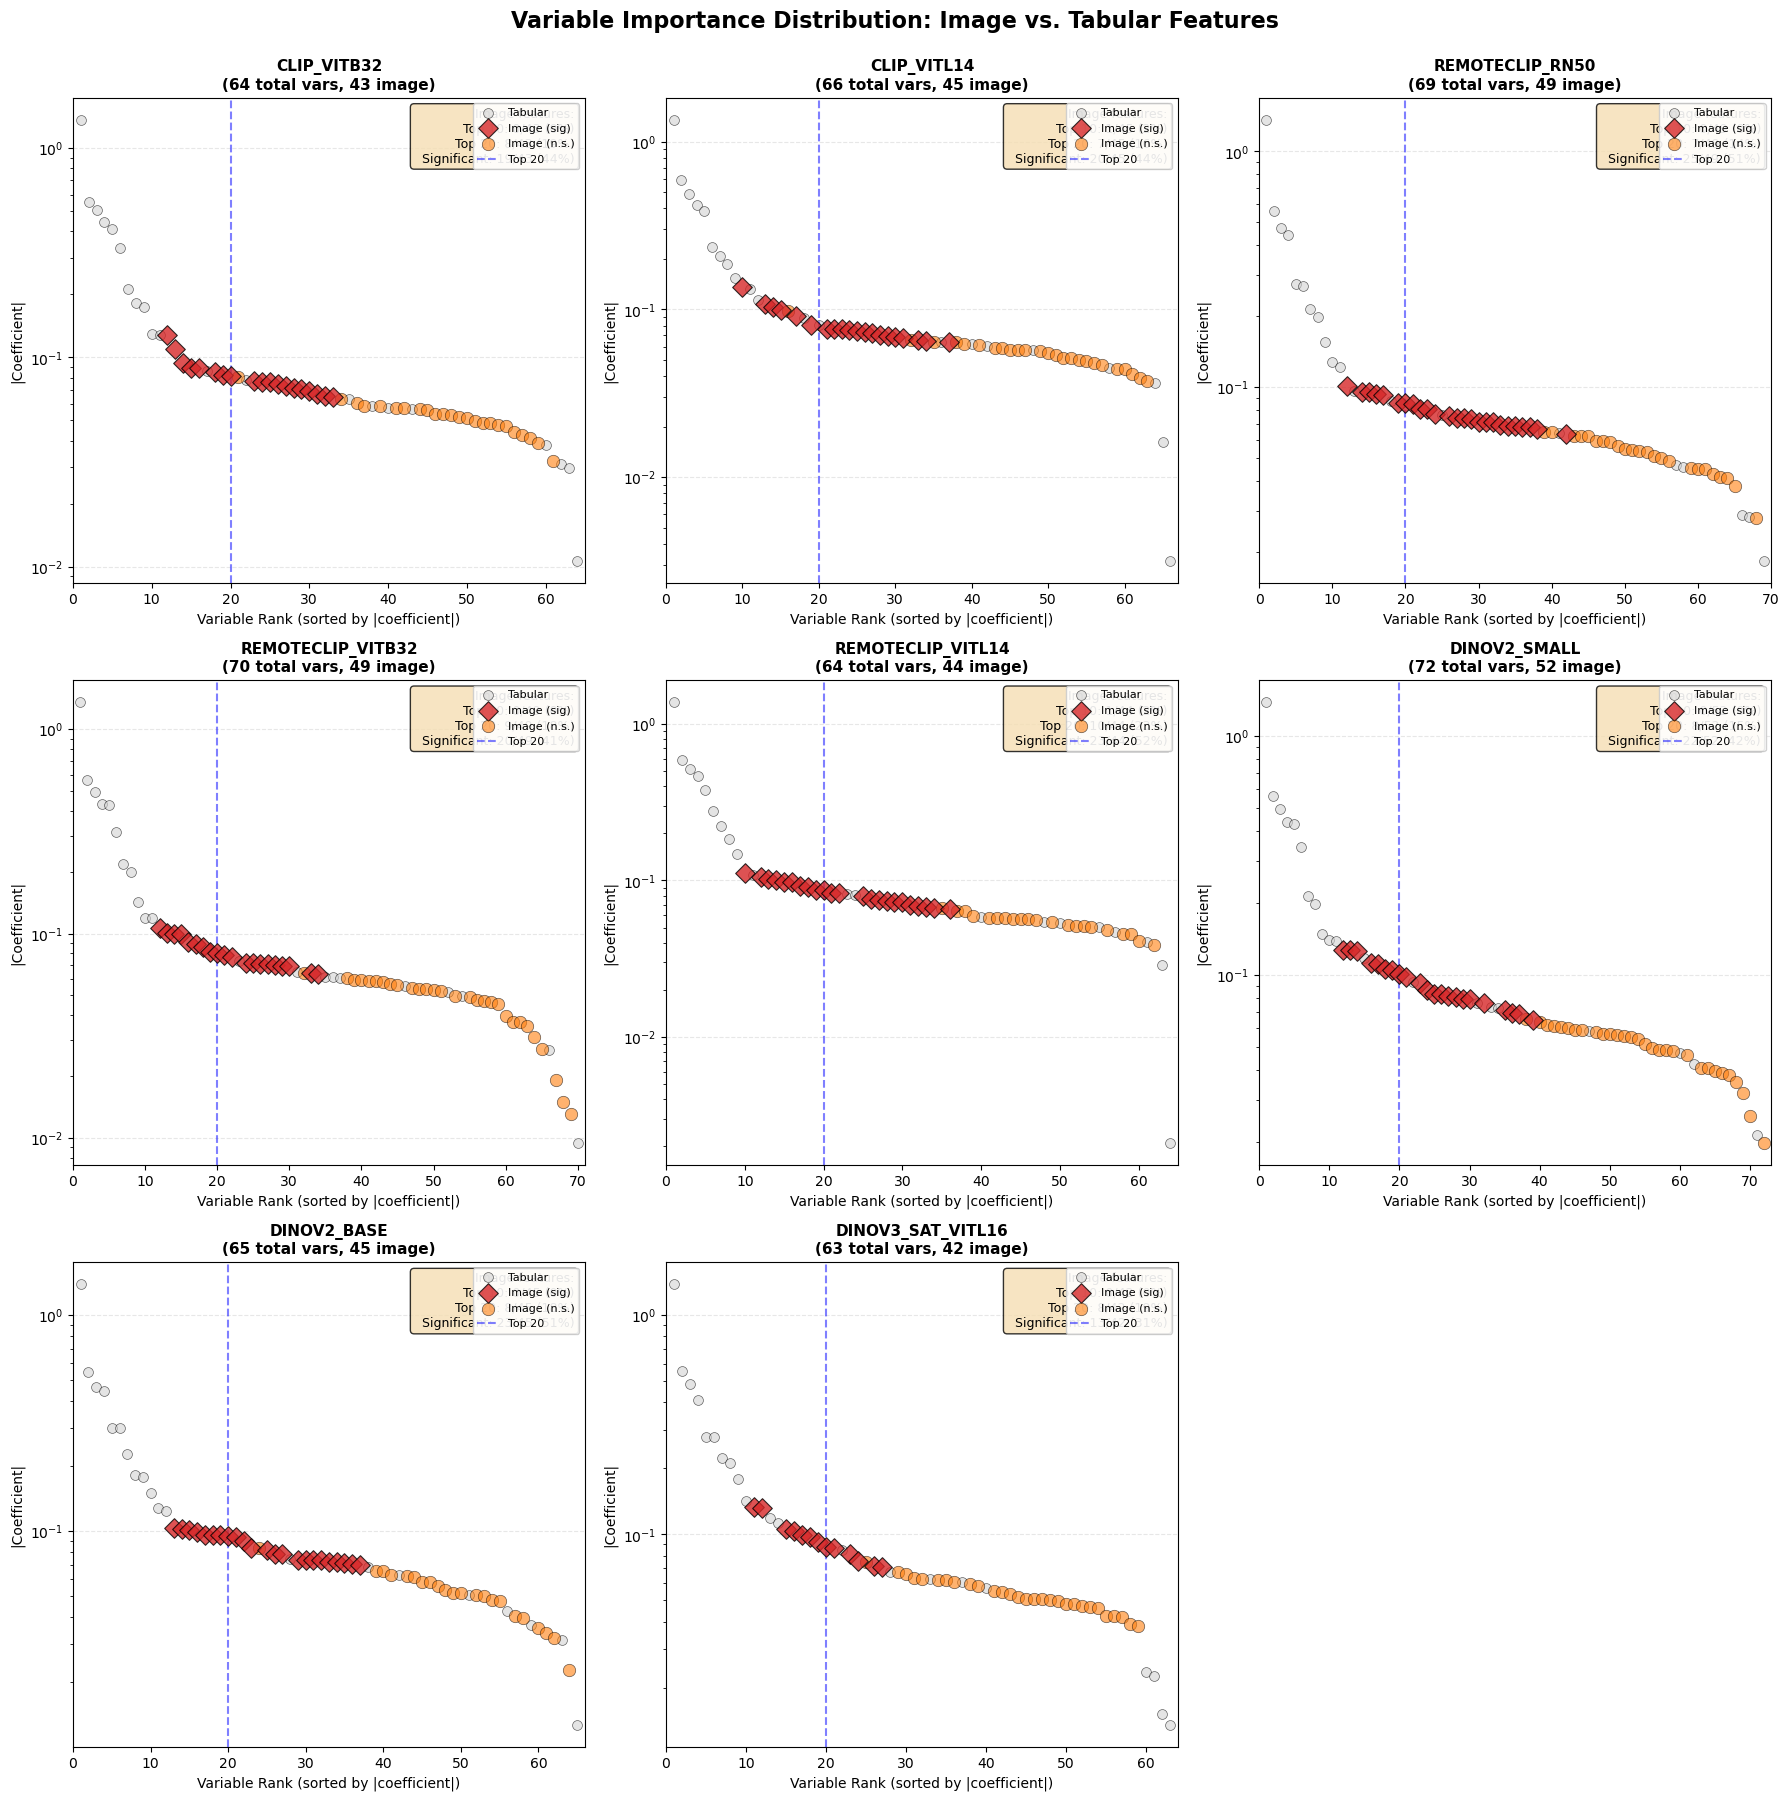


IMAGE FEATURE CONCENTRATION STATISTICS
            Model  Total Vars  Image Vars In Top 5 In Top 10  In Top 20  In Top 30 Median Rank  Highest Rank
      clip_vitb32          64          43 0 (0.0%)  0 (0.0%)  8 (18.6%) 17 (39.5%)  36 (56.2%)            12
      clip_vitl14          66          45 0 (0.0%)  1 (2.2%)  7 (15.6%) 17 (37.8%)  37 (56.1%)            10
  remoteclip_rn50          69          49 0 (0.0%)  0 (0.0%)  7 (14.3%) 16 (32.7%)  39 (56.5%)            12
remoteclip_vitb32          70          49 0 (0.0%)  0 (0.0%)  9 (18.4%) 18 (36.7%)  41 (58.6%)            12
remoteclip_vitl14          64          44 0 (0.0%)  1 (2.3%) 10 (22.7%) 18 (40.9%)  34 (53.9%)            10
     dinov2_small          72          52 0 (0.0%)  0 (0.0%)  8 (15.4%) 17 (32.7%)  42 (59.0%)            12
      dinov2_base          65          45 0 (0.0%)  0 (0.0%)  8 (17.8%) 17 (37.8%)  36 (55.4%)            13
dinov3_sat_vitl16          63          42 0 (0.0%)  0 (0.0%)  8 (19.0%) 16 (38.1%)  37 (

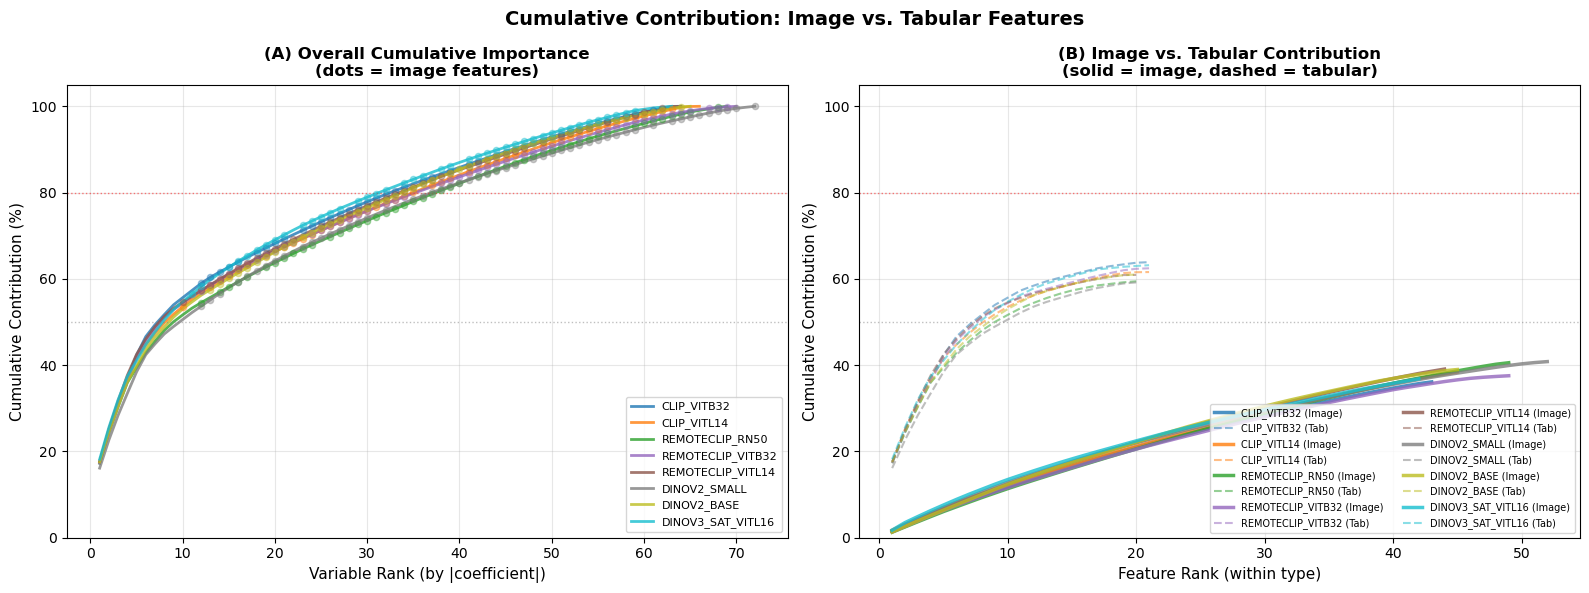


SUPPLEMENTARY ANALYSES COMPLETE

Generated outputs:
  1. Coefficient comparison table (CSV & LaTeX)
     - With image feature summary statistics
  2. Variable importance distribution plot
     - Shows image features concentrated at top ranks
  3. Image feature concentration statistics table
  4. Cumulative importance curves
     - Comparing image vs. tabular contributions

All files saved to: final_foundation_analysis_output2


In [6]:
# ============================================================================
# SUPPLEMENTARY ANALYSIS 1: Cross-Model Coefficient Comparison Table
# ============================================================================

print(f"\n{'='*80}")
print("SUPPLEMENTARY ANALYSIS 1: COEFFICIENT COMPARISON TABLE")
print(f"{'='*80}")

def create_coefficient_comparison_table(postlasso_results, tabular_feats, 
                                         person_hh, trip_f, orig_be, dest_be):
    """
    Create a comprehensive coefficient comparison table across all models.
    Format similar to Table 5 in the reference paper.
    """
    
    # Organize variables into panels
    panels = {
        'Panel 1: Sociodemographic Characteristics': person_hh,
        'Panel 2: Trip Characteristics': trip_f,
        'Panel 3: Built Environment - Origin': orig_be,
        'Panel 4: Built Environment - Destination': dest_be
    }
    
    # Get all models
    model_names = list(postlasso_results.keys())
    
    # Create table data
    table_rows = []
    
    for panel_name, variables in panels.items():
        # Add panel header
        table_rows.append({
            'Variable': f'\n{panel_name}',
            **{model: '' for model in model_names}
        })
        
        for var in variables:
            row_data = {'Variable': var}
            
            for model_name in model_names:
                coef_df = postlasso_results[model_name]['coef_df']
                
                # Find this variable in the coefficient dataframe
                var_row = coef_df[coef_df['variable'] == var]
                
                if len(var_row) > 0:
                    coef = var_row.iloc[0]['coef']
                    std_err = var_row.iloc[0]['std_err']
                    sig = var_row.iloc[0]['sig']
                    
                    # Format: coefficient (std_err) sig
                    row_data[model_name] = f"{coef:.3f}{sig}\n({std_err:.3f})"
                else:
                    row_data[model_name] = '—'
            
            table_rows.append(row_data)
    
    # ========================================================================
    # Panel 5: Imagery Features Summary (UPDATED)
    # ========================================================================
    table_rows.append({
        'Variable': f'\nPanel 5: Imagery Features Summary',
        **{model: '' for model in model_names}
    })
    
    # Total number of selected image features
    row_data = {'Variable': 'Total selected image features'}
    for model_name in model_names:
        n_img = postlasso_results[model_name]['n_img_selected']
        row_data[model_name] = str(n_img)
    table_rows.append(row_data)
    
    # Number of significant image features
    row_data = {'Variable': 'Significant image features (p<0.05)'}
    for model_name in model_names:
        n_sig = postlasso_results[model_name]['n_img_significant']
        n_total = postlasso_results[model_name]['n_img_selected']
        pct = n_sig / n_total * 100 if n_total > 0 else 0
        row_data[model_name] = f"{n_sig} ({pct:.1f}%)"
    table_rows.append(row_data)
    
    # Average absolute coefficient of image features
    row_data = {'Variable': 'Mean |coef| of image features'}
    for model_name in model_names:
        coef_df = postlasso_results[model_name]['coef_df']
        img_features = coef_df[coef_df['category'] == model_name]
        if len(img_features) > 0:
            mean_abs = img_features['abs_coef'].mean()
            row_data[model_name] = f"{mean_abs:.3f}"
        else:
            row_data[model_name] = '—'
    table_rows.append(row_data)
    
    # Max absolute coefficient of image features
    row_data = {'Variable': 'Max |coef| of image features'}
    for model_name in model_names:
        coef_df = postlasso_results[model_name]['coef_df']
        img_features = coef_df[coef_df['category'] == model_name]
        if len(img_features) > 0:
            max_abs = img_features['abs_coef'].max()
            row_data[model_name] = f"{max_abs:.3f}"
        else:
            row_data[model_name] = '—'
    table_rows.append(row_data)
    
    # Percentage of image features in top 20 variables
    row_data = {'Variable': 'Image features in top 20 variables (%)'}
    for model_name in model_names:
        coef_df = postlasso_results[model_name]['coef_df']
        # Get top 20 by absolute coefficient
        top20 = coef_df.nlargest(20, 'abs_coef')
        n_img_top20 = (top20['category'] == model_name).sum()
        pct = n_img_top20 / 20 * 100
        row_data[model_name] = f"{n_img_top20} ({pct:.0f}%)"
    table_rows.append(row_data)
    
    # ========================================================================
    # Top 3 Most Important Image Features (per model)
    # ========================================================================
    table_rows.append({
        'Variable': f'\nPanel 6: Top Image Features by Model',
        **{model: '' for model in model_names}
    })
    
    for model_name in model_names:
        coef_df = postlasso_results[model_name]['coef_df']
        img_features = coef_df[coef_df['category'] == model_name].copy()
        img_features = img_features.sort_values('abs_coef', ascending=False)
        
        if len(img_features) > 0:
            for i, (idx, row_data_item) in enumerate(img_features.head(3).iterrows()):
                var_name = row_data_item['variable']
                coef = row_data_item['coef']
                std_err = row_data_item['std_err']
                sig = row_data_item['sig']
                
                row_data = {'Variable': f'  Top {i+1}: {var_name}'}
                for m in model_names:
                    if m == model_name:
                        row_data[m] = f"{coef:.3f}{sig}\n({std_err:.3f})"
                    else:
                        row_data[m] = '—'
                table_rows.append(row_data)
    
    # ========================================================================
    # Model Fit Statistics
    # ========================================================================
    table_rows.append({
        'Variable': f'\nModel Fit Statistics',
        **{model: '' for model in model_names}
    })
    
    # Log-likelihood
    row_data = {'Variable': 'Log-Likelihood (test)'}
    for model_name in model_names:
        ll = postlasso_results[model_name]['ll_test']
        row_data[model_name] = f"{ll:.2f}"
    table_rows.append(row_data)
    
    # Pseudo R²
    row_data = {'Variable': 'Pseudo R² (test)'}
    for model_name in model_names:
        r2 = postlasso_results[model_name]['pseudo_r2_test']
        row_data[model_name] = f"{r2:.4f}"
    table_rows.append(row_data)
    
    # AUC
    row_data = {'Variable': 'AUC (test)'}
    for model_name in model_names:
        auc = postlasso_results[model_name]['auc_test']
        row_data[model_name] = f"{auc:.4f}"
    table_rows.append(row_data)
    
    # AIC
    row_data = {'Variable': 'AIC'}
    for model_name in model_names:
        aic = postlasso_results[model_name]['aic']
        row_data[model_name] = f"{aic:.1f}"
    table_rows.append(row_data)
    
    # BIC
    row_data = {'Variable': 'BIC'}
    for model_name in model_names:
        bic = postlasso_results[model_name]['bic']
        row_data[model_name] = f"{bic:.1f}"
    table_rows.append(row_data)
    
    # Sample size
    row_data = {'Variable': 'Sample size (test)'}
    for model_name in model_names:
        row_data[model_name] = str(len(y_test))
    table_rows.append(row_data)
    
    # Create DataFrame
    comparison_df = pd.DataFrame(table_rows)
    
    return comparison_df


# Generate the table
coef_comparison_table = create_coefficient_comparison_table(
    postlasso_results, tabular_feats, person_hh, trip_f, orig_be, dest_be
)

# Display the table
print("\nCOEFFICIENT COMPARISON TABLE")
print("="*150)
print(coef_comparison_table.to_string(index=False))
print("="*150)
print("\nNote: *** p < 0.001; ** p < 0.01; * p < 0.05; . p < 0.10")

# Save to CSV
coef_table_csv = config.OUTPUT_DIR / 'coefficient_comparison_table.csv'
coef_comparison_table.to_csv(coef_table_csv, index=False)
print(f"\n✓ Saved coefficient comparison table to: {coef_table_csv}")

# Also save as LaTeX format for publication
latex_output = config.OUTPUT_DIR / 'coefficient_comparison_table.tex'
with open(latex_output, 'w') as f:
    f.write("% Coefficient Comparison Table\n")
    f.write("% Generated from foundation model analysis\n\n")
    f.write(coef_comparison_table.to_latex(index=False, escape=False))
print(f"✓ Saved LaTeX table to: {latex_output}")


# ============================================================================
# SUPPLEMENTARY ANALYSIS 2: Variable Importance Distribution 
# (showing image features concentrated at the top)
# ============================================================================

print(f"\n{'='*80}")
print("SUPPLEMENTARY ANALYSIS 2: VARIABLE IMPORTANCE DISTRIBUTION")
print(f"{'='*80}")

def visualize_variable_importance_distribution(postlasso_results, output_dir):
    """
    Visualize how image features are concentrated among the most important variables.
    
    Key insight: Image features tend to cluster at the top of the importance ranking,
    suggesting they capture high-impact but specific aspects of the built environment.
    """
    
    n_models = len(postlasso_results)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Variable Importance Distribution: Image vs. Tabular Features', 
                 fontsize=16, fontweight='bold', y=0.998)
    
    for idx, (model_name, result) in enumerate(postlasso_results.items()):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        # Get all coefficients sorted by absolute value
        coef_df = result['coef_df'].copy()
        coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
        
        # Create rank
        coef_df['rank'] = np.arange(1, len(coef_df) + 1)
        
        # Separate image and tabular features
        img_features = coef_df[coef_df['category'] == model_name]
        tab_features = coef_df[coef_df['category'] != model_name]
        
        # Plot tabular features (gray)
        ax.scatter(tab_features['rank'], tab_features['abs_coef'], 
                  color='lightgray', s=50, alpha=0.6, label='Tabular', 
                  edgecolor='black', linewidth=0.5, zorder=1)
        
        # Plot image features with color by significance
        img_sig = img_features[img_features['p_value'] < 0.05]
        img_nonsig = img_features[img_features['p_value'] >= 0.05]
        
        if len(img_sig) > 0:
            ax.scatter(img_sig['rank'], img_sig['abs_coef'], 
                      color='#d62728', s=100, alpha=0.8, label='Image (sig)', 
                      marker='D', edgecolor='black', linewidth=0.8, zorder=3)
        
        if len(img_nonsig) > 0:
            ax.scatter(img_nonsig['rank'], img_nonsig['abs_coef'], 
                      color='#ff7f0e', s=80, alpha=0.6, label='Image (n.s.)', 
                      marker='o', edgecolor='black', linewidth=0.5, zorder=2)
        
        # Add vertical lines to show top-20 boundary
        ax.axvline(x=20, color='blue', linestyle='--', linewidth=1.5, 
                  alpha=0.5, label='Top 20')
        
        # Calculate statistics
        n_img_top10 = (coef_df.head(10)['category'] == model_name).sum()
        n_img_top20 = (coef_df.head(20)['category'] == model_name).sum()
        n_img_total = len(img_features)
        
        # Add text annotation
        textstr = f'Image features:\n'
        textstr += f'  Top 10: {n_img_top10}/{n_img_total} ({n_img_top10/n_img_total*100:.0f}%)\n'
        textstr += f'  Top 20: {n_img_top20}/{n_img_total} ({n_img_top20/n_img_total*100:.0f}%)\n'
        textstr += f'  Significant: {len(img_sig)}/{n_img_total} ({len(img_sig)/n_img_total*100:.0f}%)'
        
        ax.text(0.98, 0.98, textstr, transform=ax.transAxes, 
               fontsize=9, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Styling
        ax.set_xlabel('Variable Rank (sorted by |coefficient|)', fontsize=10)
        ax.set_ylabel('|Coefficient|', fontsize=10)
        ax.set_title(f'{model_name.upper()}\n({result["n_selected"]} total vars, '
                    f'{result["n_img_selected"]} image)', 
                    fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, len(coef_df) + 1)
        
        # Log scale for y-axis to better show distribution
        ax.set_yscale('log')
    
    # Hide unused subplots
    for idx in range(n_models, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    
    # Save figure
    output_path = output_dir / 'variable_importance_distribution.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved variable importance distribution to: {output_path}")
    
    output_path_pdf = output_dir / 'variable_importance_distribution.pdf'
    plt.savefig(output_path_pdf, format='pdf', bbox_inches='tight')
    print(f"✓ Saved PDF version to: {output_path_pdf}")
    
    plt.show()
    
    # ========================================================================
    # Create summary statistics table
    # ========================================================================
    
    print("\n" + "="*120)
    print("IMAGE FEATURE CONCENTRATION STATISTICS")
    print("="*120)
    
    concentration_stats = []
    
    for model_name, result in postlasso_results.items():
        coef_df = result['coef_df'].copy()
        coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
        
        n_total_vars = len(coef_df)
        n_img_total = result['n_img_selected']
        
        # Count image features in different top-k groups
        n_img_top5 = (coef_df.head(5)['category'] == model_name).sum()
        n_img_top10 = (coef_df.head(10)['category'] == model_name).sum()
        n_img_top20 = (coef_df.head(20)['category'] == model_name).sum()
        n_img_top30 = (coef_df.head(30)['category'] == model_name).sum()
        
        # Calculate percentages
        pct_top5 = n_img_top5 / n_img_total * 100 if n_img_total > 0 else 0
        pct_top10 = n_img_top10 / n_img_total * 100 if n_img_total > 0 else 0
        pct_top20 = n_img_top20 / n_img_total * 100 if n_img_total > 0 else 0
        pct_top30 = n_img_top30 / n_img_total * 100 if n_img_total > 0 else 0
        
        # Get median rank of image features
        img_ranks = coef_df[coef_df['category'] == model_name].index + 1
        median_rank = np.median(img_ranks) if len(img_ranks) > 0 else 0
        median_rank_pct = median_rank / n_total_vars * 100 if n_total_vars > 0 else 0
        
        concentration_stats.append({
            'Model': model_name,
            'Total Vars': n_total_vars,
            'Image Vars': n_img_total,
            'In Top 5': f"{n_img_top5} ({pct_top5:.1f}%)",
            'In Top 10': f"{n_img_top10} ({pct_top10:.1f}%)",
            'In Top 20': f"{n_img_top20} ({pct_top20:.1f}%)",
            'In Top 30': f"{n_img_top30} ({pct_top30:.1f}%)",
            'Median Rank': f"{median_rank:.0f} ({median_rank_pct:.1f}%)",
            'Highest Rank': int(img_ranks.min()) if len(img_ranks) > 0 else 0
        })
    
    concentration_df = pd.DataFrame(concentration_stats)
    print(concentration_df.to_string(index=False))
    print("="*120)
    print("\nInterpretation:")
    print("  • High percentage in Top 5/10/20 → Image features are among the most important")
    print("  • Low median rank → Image features concentrate at the top of importance ranking")
    print("  • This suggests image features capture high-impact aspects of built environment")
    
    # Save table
    concentration_csv = output_dir / 'image_feature_concentration.csv'
    concentration_df.to_csv(concentration_csv, index=False)
    print(f"\n✓ Saved concentration statistics to: {concentration_csv}")
    
    return concentration_df


# Generate visualization
concentration_stats_df = visualize_variable_importance_distribution(
    postlasso_results, config.OUTPUT_DIR
)


# ============================================================================
# SUPPLEMENTARY ANALYSIS 3: Cumulative Importance Curve
# ============================================================================

print(f"\n{'='*80}")
print("SUPPLEMENTARY ANALYSIS 3: CUMULATIVE IMPORTANCE CURVES")
print(f"{'='*80}")

def create_cumulative_importance_comparison(postlasso_results, output_dir):
    """
    Create cumulative importance curves comparing image vs. tabular features.
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Cumulative Contribution: Image vs. Tabular Features', 
                 fontsize=14, fontweight='bold')
    
    # Color palette
    colors = plt.cm.tab10(np.linspace(0, 1, len(postlasso_results)))
    
    for idx, (model_name, result) in enumerate(postlasso_results.items()):
        coef_df = result['coef_df'].copy()
        coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
        
        # Calculate cumulative contribution
        total_abs = coef_df['abs_coef'].sum()
        cumulative = np.cumsum(coef_df['abs_coef']) / total_abs * 100
        
        # Separate by feature type
        is_image = coef_df['category'] == model_name
        
        # Plot 1: Overall cumulative curve with feature type markers
        x = np.arange(1, len(coef_df) + 1)
        ax1.plot(x, cumulative, linewidth=2, label=model_name.upper(), 
                color=colors[idx], alpha=0.8)
        
        # Mark where image features are
        img_positions = x[is_image]
        img_cumulative = cumulative[is_image]
        ax1.scatter(img_positions, img_cumulative, s=20, color=colors[idx], 
                   alpha=0.4, marker='o', zorder=3)
        
        # Plot 2: Compare cumulative contribution of image vs tabular
        img_features = coef_df[is_image].copy()
        tab_features = coef_df[~is_image].copy()
        
        if len(img_features) > 0:
            img_cumsum = np.cumsum(img_features['abs_coef']) / total_abs * 100
            img_x = np.arange(1, len(img_features) + 1)
            ax2.plot(img_x, img_cumsum, linewidth=2.5, 
                    label=f'{model_name.upper()} (Image)', 
                    color=colors[idx], linestyle='-', alpha=0.8)
        
        if len(tab_features) > 0:
            tab_cumsum = np.cumsum(tab_features['abs_coef']) / total_abs * 100
            tab_x = np.arange(1, len(tab_features) + 1)
            ax2.plot(tab_x, tab_cumsum, linewidth=1.5, 
                    label=f'{model_name.upper()} (Tab)', 
                    color=colors[idx], linestyle='--', alpha=0.5)
    
    # Styling for Plot 1
    ax1.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax1.axhline(y=80, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax1.set_xlabel('Variable Rank (by |coefficient|)', fontsize=11)
    ax1.set_ylabel('Cumulative Contribution (%)', fontsize=11)
    ax1.set_title('(A) Overall Cumulative Importance\n(dots = image features)', 
                 fontsize=12, fontweight='bold')
    ax1.legend(fontsize=8, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 105)
    
    # Styling for Plot 2
    ax2.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax2.axhline(y=80, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Feature Rank (within type)', fontsize=11)
    ax2.set_ylabel('Cumulative Contribution (%)', fontsize=11)
    ax2.set_title('(B) Image vs. Tabular Contribution\n(solid = image, dashed = tabular)', 
                 fontsize=12, fontweight='bold')
    ax2.legend(fontsize=7, loc='lower right', ncol=2)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 105)
    
    plt.tight_layout()
    
    # Save
    output_path = output_dir / 'cumulative_importance_comparison.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved cumulative importance comparison to: {output_path}")
    
    output_path_pdf = output_dir / 'cumulative_importance_comparison.pdf'
    plt.savefig(output_path_pdf, format='pdf', bbox_inches='tight')
    print(f"✓ Saved PDF version to: {output_path_pdf}")
    
    plt.show()


# Generate cumulative importance comparison
create_cumulative_importance_comparison(postlasso_results, config.OUTPUT_DIR)

print(f"\n{'='*80}")
print("SUPPLEMENTARY ANALYSES COMPLETE")
print(f"{'='*80}")
print(f"\nGenerated outputs:")
print(f"  1. Coefficient comparison table (CSV & LaTeX)")
print(f"     - With image feature summary statistics")
print(f"  2. Variable importance distribution plot")
print(f"     - Shows image features concentrated at top ranks")
print(f"  3. Image feature concentration statistics table")
print(f"  4. Cumulative importance curves")
print(f"     - Comparing image vs. tabular contributions")
print(f"\nAll files saved to: {config.OUTPUT_DIR}")

In [5]:
!pip install --upgrade jinja2

Defaulting to user installation because normal site-packages is not writeable
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)


In [5]:
import matplotlib.pyplot as plt

In [6]:
!pip install open-clip-torch

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [open-clip-torch] [open-clip-torch]


In [6]:
# ============================================================================
# CLIP ZERO-SHOT SEMANTIC ALIGNMENT (UPDATED)
# ============================================================================

print(f"\n{'='*80}")
print("STEP 6: CLIP ZERO-SHOT SEMANTIC ALIGNMENT")
print(f"{'='*80}")

if 'clip_vitb32' in embeddings_dict and has_open_clip:
    try:
        import open_clip
        from scipy.stats import pearsonr, ttest_ind
        
        # ====================================================================
        # Load CLIP model
        # ====================================================================
        print(f"\n[6.1] Loading CLIP model for text encoding...")
        model, _, preprocess = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai'
        )
        model = model.to(device).eval()
        tokenizer = open_clip.tokenize
        
        # ====================================================================
        # Define hierarchical urban concepts
        # ====================================================================
        print(f"\n[6.2] Defining hierarchical urban planning concepts...")
        
        # Tier 1: Traditional 5D Built Environment Concepts
        tier1_concepts = {
            # Density
            "high_density_urban": "High-density urban fabric, tightly packed multi-story buildings",
            "low_density_suburban": "Low-density suburban sprawl, sparse single-family housing",
            
            # Diversity
            "mixed_use": "Mixed-use neighborhood, integrated retail and residential roofs",
            "single_use": "Homogeneous residential monoculture, uniform housing units",
            
            # Design
            "grid_network": "Grid street network, high intersection density",
            "cul_de_sac": "Cul-de-sac street patterns, fragmented road network",
            
            # Accessibility
            "central_cbd": "Central business district, dense office clusters",
            "remote_fringe": "Remote suburban fringe, isolated from urban centers",
            
            # Distance to Transit
            "tod": "Transit-oriented development near rail station",
            "car_dependent": "Car-dependent landscape, no public transit infrastructure"
        }
        
        # Tier 2: Satellite-Specific Physical Features
        tier2_concepts = {
            # Vegetation
            "dense_tree_canopy": "dense urban tree canopy providing significant shade over streets",
            "barren_landscape": "barren urban landscape with minimal tree cover and vegetation",
            
            # Building Footprint
            "tight_building_footprint": "tight building footprints with high lot coverage and small setbacks",
            "low_lot_coverage": "low building lot coverage with large private yards and open spaces",
            
            # Parking
            "minimal_parking": "minimal surface parking with hidden or underground garages",
            "large_parking_lots": "large expanses of asphalt surface parking lots dominating the view",
            
            # Street Design
            "narrow_streets": "human-scale narrow streets designed for slow traffic",
            "wide_arterial": "oversized wide multi-lane roads and high-speed arterial highways",
            
            # Waterfront
            "accessible_waterfront": "accessible waterfront with public promenades and green parks",
            "industrial_waterfront": "degraded industrial waterfront with no public pedestrian access",
            
            # Infrastructure
            "green_infrastructure": "porous green infrastructure with integrated rain gardens",
            "grey_infrastructure": "solid impervious grey infrastructure with concrete and asphalt"
        }
        
        # Tier 3: Data-Derived Morphological Patterns
        tier3_concepts = {
            "transit_village": "pedestrian-prioritized transit village with compact development",
            "commercial_strip": "automobile-dependent commercial strip with large parking buffers",
            "fine_grain_urban": "fine-grained urban morphology with small blocks and frequent doors",
            "coarse_grain_industrial": "coarse-grained industrial morphology with massive warehouses",
            "active_streetscape": "active urban streetscape with continuous sidewalk networks",
            "passive_suburban": "passive suburban landscape with fragmented or missing sidewalks",
            "tod_high_intensity": "transit-oriented development (TOD) with high-intensity land use",
            "car_centric_sprawl": "car-centric urban sprawl with fragmented natural patches"
        }
        
        # Combine all concepts
        all_concepts = {
            **{f"T1_{k}": v for k, v in tier1_concepts.items()},
            **{f"T2_{k}": v for k, v in tier2_concepts.items()},
            **{f"T3_{k}": v for k, v in tier3_concepts.items()}
        }
        
        concept_names = list(all_concepts.keys())
        concept_texts = list(all_concepts.values())
        
        print(f"  Tier 1 (5D Built Environment): {len(tier1_concepts)} concepts")
        print(f"  Tier 2 (Satellite Features): {len(tier2_concepts)} concepts")
        print(f"  Tier 3 (Morphological Patterns): {len(tier3_concepts)} concepts")
        print(f"  Total concepts: {len(all_concepts)}")
        
        # ====================================================================
        # Encode all concept texts
        # ====================================================================
        print(f"\n[6.3] Encoding text concepts...")
        text_tokens = tokenizer(concept_texts).to(device)
        with torch.no_grad():
            text_features = model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        print(f"  Encoded {len(concept_texts)} text concepts")
        
        # ====================================================================
        # Get CLIP embeddings and compute similarities
        # ====================================================================
        print(f"\n[6.4] Computing text-image similarities...")
        clip_embeddings = embeddings_dict['clip_vitb32']['embeddings']
        clip_embeddings_tensor = torch.from_numpy(clip_embeddings).float().to(device)
        clip_embeddings_tensor = clip_embeddings_tensor / clip_embeddings_tensor.norm(
            dim=-1, keepdim=True
        )
        
        # Compute similarities: (N_locations, N_concepts)
        similarities = clip_embeddings_tensor @ text_features.T
        similarities_np = similarities.cpu().numpy()
        
        print(f"  Similarity matrix shape: {similarities_np.shape}")
        
        # ====================================================================
        # Multi-concept assignment for each image
        # ====================================================================
        print(f"\n[6.5] Assigning multiple concepts to each location...")
        
        # For each location, get top-k matching concepts
        top_k = 5  # Number of concepts per image
        
        location_concepts = []
        for loc_idx in range(len(similarities_np)):
            top_indices = np.argsort(similarities_np[loc_idx])[-top_k:][::-1]
            top_concepts = []
            
            for idx in top_indices:
                top_concepts.append({
                    'concept_name': concept_names[idx],
                    'concept_text': concept_texts[idx],
                    'similarity': similarities_np[loc_idx, idx]
                })
            
            location_concepts.append({
                'location_idx': loc_idx,
                'top_concepts': top_concepts
            })
        
        print(f"  Assigned top-{top_k} concepts to {len(location_concepts)} locations")
        
        # ====================================================================
        # Analyze concept-mode choice correlations
        # ====================================================================
        print(f"\n[6.6] Analyzing concept-transit correlations...")
        
        concept_mode_correlations = []
        
        for concept_idx, concept_name in enumerate(concept_names):
            concept_text = concept_texts[concept_idx]
            
            # Origin correlations
            trip_similarities_orig = []
            trip_modes = []
            
            for trip_idx in range(len(df)):
                orig_emb_idx = df.iloc[trip_idx]['orig_emb_idx']
                if 0 <= orig_emb_idx < len(similarities_np):
                    trip_similarities_orig.append(similarities_np[orig_emb_idx, concept_idx])
                    trip_modes.append(df.iloc[trip_idx]['is_transit'])
            
            if len(trip_similarities_orig) < 100:
                continue
            
            # Compute correlation for origins
            corr_orig, p_orig = pearsonr(trip_similarities_orig, trip_modes)
            
            # Destination correlations
            trip_similarities_dest = []
            trip_modes_dest = []
            
            for trip_idx in range(len(df)):
                dest_emb_idx = df.iloc[trip_idx]['dest_emb_idx']
                if 0 <= dest_emb_idx < len(similarities_np):
                    trip_similarities_dest.append(similarities_np[dest_emb_idx, concept_idx])
                    trip_modes_dest.append(df.iloc[trip_idx]['is_transit'])
            
            corr_dest, p_dest = pearsonr(trip_similarities_dest, trip_modes_dest)
            
            # Combined correlation (average)
            corr_combined = (corr_orig + corr_dest) / 2
            
            # Determine tier
            if concept_name.startswith('T1_'):
                tier = 'Tier 1: 5D Built Environment'
            elif concept_name.startswith('T2_'):
                tier = 'Tier 2: Satellite Features'
            else:
                tier = 'Tier 3: Morphological Patterns'
            
            concept_mode_correlations.append({
                'tier': tier,
                'concept_name': concept_name,
                'concept_text': concept_text,
                'corr_origin': corr_orig,
                'p_origin': p_orig,
                'corr_dest': corr_dest,
                'p_dest': p_dest,
                'corr_combined': corr_combined,
                'sig_origin': sig_stars(p_orig),
                'sig_dest': sig_stars(p_dest)
            })
        
        # Create DataFrame
        concept_df = pd.DataFrame(concept_mode_correlations)
        
        # ====================================================================
        # Print results by tier
        # ====================================================================
        print(f"\n{'='*100}")
        print("CONCEPT-TRANSIT CORRELATIONS BY TIER")
        print(f"{'='*100}")
        
        for tier in ['Tier 1: 5D Built Environment', 
                     'Tier 2: Satellite Features', 
                     'Tier 3: Morphological Patterns']:
            tier_df = concept_df[concept_df['tier'] == tier].sort_values(
                'corr_combined', ascending=False
            )
            
            print(f"\n{tier}")
            print(f"{'-'*100}")
            print(f"{'Concept':<40} {'Corr(O)':>10} {'Sig':>5} {'Corr(D)':>10} {'Sig':>5} {'Combined':>10}")
            print(f"{'-'*100}")
            
            for _, row in tier_df.iterrows():
                concept_short = row['concept_name'].replace('T1_', '').replace('T2_', '').replace('T3_', '')
                print(f"{concept_short:<40} {row['corr_origin']:>+10.3f} {row['sig_origin']:>5} "
                      f"{row['corr_dest']:>+10.3f} {row['sig_dest']:>5} {row['corr_combined']:>+10.3f}")
        
        # ====================================================================
        # Summary statistics by tier
        # ====================================================================
        print(f"\n{'='*100}")
        print("SUMMARY STATISTICS BY TIER")
        print(f"{'='*100}")
        
        tier_summary = concept_df.groupby('tier').agg({
            'corr_origin': ['mean', 'std', 'min', 'max'],
            'corr_dest': ['mean', 'std', 'min', 'max'],
            'corr_combined': ['mean', 'std', 'min', 'max']
        }).round(3)
        
        print(tier_summary)
        
        # ====================================================================
        # Top transit-promoting and auto-promoting concepts
        # ====================================================================
        print(f"\n{'='*100}")
        print("TOP TRANSIT-PROMOTING CONCEPTS (across all tiers)")
        print(f"{'='*100}")
        
        top_transit = concept_df.sort_values('corr_combined', ascending=False).head(10)
        
        for i, (_, row) in enumerate(top_transit.iterrows(), 1):
            print(f"\n{i}. {row['concept_name']}")
            print(f"   Text: {row['concept_text']}")
            print(f"   Corr (Origin): {row['corr_origin']:+.3f} {row['sig_origin']}")
            print(f"   Corr (Dest):   {row['corr_dest']:+.3f} {row['sig_dest']}")
            print(f"   Combined:      {row['corr_combined']:+.3f}")
        
        print(f"\n{'='*100}")
        print("TOP AUTO-PROMOTING CONCEPTS (across all tiers)")
        print(f"{'='*100}")
        
        top_auto = concept_df.sort_values('corr_combined', ascending=True).head(10)
        
        for i, (_, row) in enumerate(top_auto.iterrows(), 1):
            print(f"\n{i}. {row['concept_name']}")
            print(f"   Text: {row['concept_text']}")
            print(f"   Corr (Origin): {row['corr_origin']:+.3f} {row['sig_origin']}")
            print(f"   Corr (Dest):   {row['corr_dest']:+.3f} {row['sig_dest']}")
            print(f"   Combined:      {row['corr_combined']:+.3f}")
        
        # ====================================================================
        # Create visualization: Heatmap of concept correlations
        # ====================================================================
        print(f"\n[6.7] Creating visualizations...")
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 8))
        fig.suptitle('CLIP Zero-Shot Concept-Transit Correlations by Tier', 
                     fontsize=16, fontweight='bold')
        
        for idx, tier in enumerate(['Tier 1: 5D Built Environment', 
                                     'Tier 2: Satellite Features', 
                                     'Tier 3: Morphological Patterns']):
            ax = axes[idx]
            tier_df = concept_df[concept_df['tier'] == tier].sort_values('corr_combined')
            
            # Prepare data for heatmap
            concepts = [c.replace('T1_', '').replace('T2_', '').replace('T3_', '')[:30] 
                       for c in tier_df['concept_name']]
            corr_orig = tier_df['corr_origin'].values
            corr_dest = tier_df['corr_dest'].values
            
            # Create grouped bar chart
            y_pos = np.arange(len(concepts))
            width = 0.35
            
            bars1 = ax.barh(y_pos - width/2, corr_orig, width, 
                           label='Origin', alpha=0.8, color='steelblue')
            bars2 = ax.barh(y_pos + width/2, corr_dest, width,
                           label='Destination', alpha=0.8, color='coral')
            
            ax.set_yticks(y_pos)
            ax.set_yticklabels(concepts, fontsize=8)
            ax.set_xlabel('Correlation with Transit Choice', fontsize=10)
            ax.set_title(tier.replace('Tier ', 'T'), fontsize=12, fontweight='bold')
            ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
            ax.grid(axis='x', alpha=0.3, linestyle='--')
            ax.legend(fontsize=9)
        
        plt.tight_layout()
        
        # Save visualization
        viz_path = config.OUTPUT_DIR / 'clip_zeroshot_concept_correlations.png'
        plt.savefig(viz_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved visualization to: {viz_path}")
        plt.close()
        
        # ====================================================================
        # Save detailed results
        # ====================================================================
        
        # Save concept correlations
        clip_csv = config.OUTPUT_DIR / 'clip_zeroshot_concepts_detailed.csv'
        concept_df.to_csv(clip_csv, index=False)
        print(f"  ✓ Saved detailed results to: {clip_csv}")
        
        # Save location-concept assignments
        location_concepts_df = []
        for loc_data in location_concepts[:100]:  # Save first 100 for inspection
            loc_idx = loc_data['location_idx']
            for rank, concept_info in enumerate(loc_data['top_concepts'], 1):
                location_concepts_df.append({
                    'location_idx': loc_idx,
                    'rank': rank,
                    'concept_name': concept_info['concept_name'],
                    'concept_text': concept_info['concept_text'],
                    'similarity': concept_info['similarity']
                })
        
        loc_concepts_csv = config.OUTPUT_DIR / 'location_concept_assignments_sample.csv'
        pd.DataFrame(location_concepts_df).to_csv(loc_concepts_csv, index=False)
        print(f"  ✓ Saved location-concept assignments to: {loc_concepts_csv}")
        
        # ====================================================================
        # Create tier comparison summary table
        # ====================================================================
        tier_comparison = []
        
        for tier in ['Tier 1: 5D Built Environment', 
                     'Tier 2: Satellite Features', 
                     'Tier 3: Morphological Patterns']:
            tier_df = concept_df[concept_df['tier'] == tier]
            
            # Count significant concepts
            sig_orig = (tier_df['p_origin'] < 0.05).sum()
            sig_dest = (tier_df['p_dest'] < 0.05).sum()
            
            # Get strongest pro-transit and pro-auto
            strongest_transit = tier_df.loc[tier_df['corr_combined'].idxmax()]
            strongest_auto = tier_df.loc[tier_df['corr_combined'].idxmin()]
            
            tier_comparison.append({
                'Tier': tier,
                'N Concepts': len(tier_df),
                'Sig at Origin (p<0.05)': sig_orig,
                'Sig at Dest (p<0.05)': sig_dest,
                'Mean |Corr|': tier_df['corr_combined'].abs().mean(),
                'Strongest Pro-Transit': strongest_transit['concept_name'],
                'Pro-Transit Corr': strongest_transit['corr_combined'],
                'Strongest Pro-Auto': strongest_auto['concept_name'],
                'Pro-Auto Corr': strongest_auto['corr_combined']
            })
        
        tier_comp_df = pd.DataFrame(tier_comparison)
        
        print(f"\n{'='*100}")
        print("TIER COMPARISON SUMMARY")
        print(f"{'='*100}")
        print(tier_comp_df.to_string(index=False))
        
        # Save tier comparison
        tier_comp_csv = config.OUTPUT_DIR / 'clip_tier_comparison.csv'
        tier_comp_df.to_csv(tier_comp_csv, index=False)
        print(f"\n  ✓ Saved tier comparison to: {tier_comp_csv}")
        
        print(f"\n{'='*80}")
        print("CLIP ZERO-SHOT ANALYSIS COMPLETE")
        print(f"{'='*80}")
        print(f"\nGenerated outputs:")
        print(f"  • Detailed concept correlations (by tier)")
        print(f"  • Location-concept assignments (top-5 per location)")
        print(f"  • Visualization: correlation heatmap by tier")
        print(f"  • Tier comparison summary table")
        
    except Exception as e:
        print(f"\n  ✗ CLIP zero-shot analysis failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n  ⚠️ CLIP not available, skipping zero-shot analysis")


STEP 6: CLIP ZERO-SHOT SEMANTIC ALIGNMENT

[6.1] Loading CLIP model for text encoding...

[6.2] Defining hierarchical urban planning concepts...
  Tier 1 (5D Built Environment): 10 concepts
  Tier 2 (Satellite Features): 12 concepts
  Tier 3 (Morphological Patterns): 8 concepts
  Total concepts: 30

[6.3] Encoding text concepts...
  Encoded 30 text concepts

[6.4] Computing text-image similarities...
  Similarity matrix shape: (1148, 30)

[6.5] Assigning multiple concepts to each location...
  Assigned top-5 concepts to 1148 locations

[6.6] Analyzing concept-transit correlations...

CONCEPT-TRANSIT CORRELATIONS BY TIER

Tier 1: 5D Built Environment
----------------------------------------------------------------------------------------------------
Concept                                     Corr(O)   Sig    Corr(D)   Sig   Combined
----------------------------------------------------------------------------------------------------
high_density_urban                           +0.027  

In [9]:
# ADVANCED IMAGE-TEXT INTERPRETATION: LINKING MODEL RESULTS TO SEMANTICS

print(f"\n{'='*80}")
print("STEP 7: ADVANCED IMAGERY-TEXT INTERPRETATION")
print(f"{'='*80}")

if has_open_clip:
    try:
        import open_clip
        from scipy.stats import pearsonr
        from PIL import Image
        import matplotlib.pyplot as plt
        import matplotlib.gridspec as gridspec
        from matplotlib.patches import Rectangle
        import textwrap
        import pandas as pd
        import numpy as np
        import torch
        from torch.utils.data import DataLoader
        from pathlib import Path
        
        # ====================================================================
        # [7.1] Load CLIP model and define concepts
        # ====================================================================
        print(f"\n[7.1] Loading CLIP model for interpretation...")
        
        model, _, preprocess = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai'
        )
        model = model.to(device).eval()
        tokenizer = open_clip.tokenize
        
        # Define hierarchical urban concepts
        tier1_concepts = {
            "high_density_urban": "High-density urban fabric, tightly packed multi-story buildings",
            "low_density_suburban": "Low-density suburban sprawl, sparse single-family housing",
            "mixed_use": "Mixed-use neighborhood, integrated retail and residential",
            "single_use": "Homogeneous residential monoculture, uniform housing units",
            "grid_network": "Grid street network, high intersection density",
            "cul_de_sac": "Cul-de-sac street patterns, fragmented road network",
            "central_cbd": "Central business district, dense office clusters",
            "remote_fringe": "Remote suburban fringe, isolated from urban centers",
            "tod": "Transit-oriented development near rail station",
            "car_dependent": "Car-dependent landscape, no public transit infrastructure"
        }
        
        tier2_concepts = {
            "dense_tree_canopy": "Dense urban tree canopy providing significant shade over streets",
            "barren_landscape": "Barren urban landscape with minimal tree cover and vegetation",
            "tight_building_footprint": "Tight building footprints with high lot coverage and small setbacks",
            "low_lot_coverage": "Low building lot coverage with large private yards and open spaces",
            "minimal_parking": "Minimal surface parking with hidden or underground garages",
            "large_parking_lots": "Large expanses of asphalt surface parking lots dominating the view",
            "narrow_streets": "Human-scale narrow streets designed for slow traffic",
            "wide_arterial": "Oversized wide multi-lane roads and high-speed arterial highways",
            "accessible_waterfront": "Accessible waterfront with public promenades and green parks",
            "industrial_waterfront": "Degraded industrial waterfront with no public pedestrian access",
            "green_infrastructure": "Porous green infrastructure with integrated rain gardens",
            "grey_infrastructure": "Solid impervious grey infrastructure with concrete and asphalt"
        }
        
        tier3_concepts = {
            "transit_village": "Pedestrian-prioritized transit village with compact development",
            "commercial_strip": "Automobile-dependent commercial strip with large parking buffers",
            "fine_grain_urban": "Fine-grained urban morphology with small blocks and frequent doors",
            "coarse_grain_industrial": "Coarse-grained industrial morphology with massive warehouses",
            "active_streetscape": "Active urban streetscape with continuous sidewalk networks",
            "passive_suburban": "Passive suburban landscape with fragmented or missing sidewalks",
            "tod_high_intensity": "Transit-oriented development with high-intensity land use",
            "car_centric_sprawl": "Car-centric urban sprawl with fragmented natural patches"
        }
        
        all_concepts = {
            **{f"T1_{k}": v for k, v in tier1_concepts.items()},
            **{f"T2_{k}": v for k, v in tier2_concepts.items()},
            **{f"T3_{k}": v for k, v in tier3_concepts.items()}
        }
        
        concept_names = list(all_concepts.keys())
        concept_texts = list(all_concepts.values())
        
        # Encode text concepts
        text_tokens = tokenizer(concept_texts).to(device)
        with torch.no_grad():
            text_features = model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        # ====================================================================
        # [7.2] Select best model and load saved components
        # ====================================================================
        print(f"\n[7.2] Selecting best model and loading components...")
        
        best_model_name = max(
            postlasso_results.keys(),
            key=lambda k: postlasso_results[k]['pseudo_r2_test']
        )
        
        model_results = postlasso_results[best_model_name]
        coef_df = model_results['coef_df'].copy()
        pca_obj = model_results['pca']
        scaler_obj = model_results['scaler']
        embeddings = embeddings_dict[best_model_name]['embeddings']
        
        # Compute CLIP similarities for images
        clip_dataset = SatelliteDataset(emb_index, transform=preprocess)
        clip_loader = DataLoader(clip_dataset, batch_size=32, shuffle=False)
        
        clip_image_features = []
        with torch.no_grad():
            for batch in clip_loader:
                imgs = batch['image'].to(device)
                img_feat = model.encode_image(imgs)
                img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
                clip_image_features.append(img_feat.cpu())
        
        clip_image_features = torch.cat(clip_image_features, dim=0).numpy()
        similarities_np = clip_image_features @ text_features.cpu().numpy().T
        
        # Get significant features
        sig_img_features = coef_df[
            (coef_df['category'] == best_model_name) & (coef_df['p_value'] < 0.05)
        ].copy()
        
        sig_img_features['pc_number'] = sig_img_features['variable'].apply(lambda x: int(x.split('_pc')[-1]))
        sig_img_features['abs_coef'] = sig_img_features['coef'].abs()
        sig_img_features['direction'] = sig_img_features['coef'].apply(lambda x: 'Pro-Transit' if x > 0 else 'Pro-Auto')
        
        # ====================================================================
        # [7.3] Identify exemplar locations for significant PCs
        # ====================================================================
        print(f"\n[7.3] Identifying exemplar locations...")
        
        def get_pc_loadings(embeddings, pca_obj, scaler_obj, pc_index):
            embeddings_scaled = scaler_obj.transform(embeddings)
            embeddings_pca = pca_obj.transform(embeddings_scaled)
            return embeddings_pca[:, pc_index]

        selected_features = pd.concat([
            sig_img_features.nlargest(3, 'coef'),
            sig_img_features.nsmallest(3, 'coef')
        ]).sort_values('abs_coef', ascending=False)
        
        exemplar_analysis = []
        for _, feature_row in selected_features.iterrows():
            pc_num = feature_row['pc_number']
            pc_loadings = get_pc_loadings(embeddings, pca_obj, scaler_obj, pc_num - 1)
            
            top_indices = np.argsort(pc_loadings)[-5:][::-1]
            bottom_indices = np.argsort(pc_loadings)[:5]
            
            exemplar_analysis.append({
                'variable': feature_row['variable'],
                'pc_number': pc_num,
                'coefficient': feature_row['coef'],
                'p_value': feature_row['p_value'],
                'direction': feature_row['direction'],
                'exemplars': {
                    'top_indices': top_indices, 'top_loadings': pc_loadings[top_indices],
                    'bottom_indices': bottom_indices, 'bottom_loadings': pc_loadings[bottom_indices]
                }
            })

        # ====================================================================
        # [7.4] & [7.5] Interpret locations and Generate Narratives
        # ====================================================================
        def interpret_location(loc_idx, similarities_np, names, texts):
            sims = similarities_np[loc_idx]
            top_idx = np.argsort(sims)[-5:][::-1]
            return [{'concept_name': names[i], 'concept_text': texts[i], 
                     'similarity': sims[i], 'tier': names[i].split('_')[0]} for i in top_idx]

        def synthesize_narrative(interpretations):
            t1, t2, t3 = [], [], []
            for interp_set in interpretations:
                for c in interp_set['concepts'][:3]:
                    if c['tier'] == 'T1': t1.append(c['concept_text'])
                    elif c['tier'] == 'T2': t2.append(c['concept_text'])
                    else: t3.append(c['concept_text'])
            parts = []
            if t1: parts.append(f"characterized by {', '.join(list(dict.fromkeys(t1))[:2]).lower()}")
            if t2: parts.append(f"showing {', '.join(list(dict.fromkeys(t2))[:2]).lower()}")
            if t3: parts.append(f"exhibiting {', '.join(list(dict.fromkeys(t3))[:2]).lower()}")
            return ". ".join(parts).capitalize() + "."

        for analysis in exemplar_analysis:
            analysis['top_interpretations'] = [
                {'location_idx': idx, 'loading': analysis['exemplars']['top_loadings'][i],
                 'concepts': interpret_location(idx, similarities_np, concept_names, concept_texts)} 
                for i, idx in enumerate(analysis['exemplars']['top_indices'][:3])
            ]
            analysis['bottom_interpretations'] = [
                {'location_idx': idx, 'loading': analysis['exemplars']['bottom_loadings'][i],
                 'concepts': interpret_location(idx, similarities_np, concept_names, concept_texts)} 
                for i, idx in enumerate(analysis['exemplars']['bottom_indices'][:3])
            ]
            analysis['top_narrative'] = synthesize_narrative(analysis['top_interpretations'])
            analysis['bottom_narrative'] = synthesize_narrative(analysis['bottom_interpretations'])

        # ====================================================================
        # [7.6] Create journal-quality visualization (Merged Logic)
        # ====================================================================
        print(f"\n[7.6] Creating journal-quality figures...")

        def get_image_path(emb_index, loc_idx):
            """Helper to find image path with fallback logic."""
            if loc_idx < 0 or loc_idx >= len(emb_index): return None
            loc_row = emb_index.iloc[loc_idx]
            
            if 'satellite_image_path' in loc_row:
                img_path = Path(loc_row['satellite_image_path'])
                if img_path.exists(): return img_path
            
            point_id, lat, lon = loc_row['point_id'], loc_row['lat'], loc_row['lon']
            image_dir = Path(config.ADAPTIVE_DIR) if hasattr(config, 'ADAPTIVE_DIR') else Path('./satellite_images_points')
            
            # Try Patterns
            p1 = image_dir / f"point{point_id}_{lat}_{lon}.png"
            if p1.exists(): return p1
            
            if 'tract_id' in loc_row and loc_row['tract_id'] is not None:
                p2 = image_dir / f"point{point_id}_tract{loc_row['tract_id']}_{lat}_{lon}.png"
                if p2.exists(): return p2
            return None

        def create_interpretation_figure(analysis_item, emb_index, output_path):
            """Create a publication-quality figure."""
            var_name = analysis_item['variable']
            coef, p_val, direction = analysis_item['coefficient'], analysis_item['p_value'], analysis_item['direction']
            
            fig = plt.figure(figsize=(18, 12))
            gs = gridspec.GridSpec(4, 4, figure=fig, height_ratios=[0.8, 3, 3, 1.5], hspace=0.35, wspace=0.3)
            plt.rcParams['font.family'] = 'sans-serif'
            
            # Title
            ax_title = fig.add_subplot(gs[0, :])
            ax_title.axis('off')
            sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*'
            title_text = (f"Imagery Embedding Interpretation: {var_name.replace('_', ' ').upper()}\n"
                          f"Coefficient: β = {coef:.4f} ({direction}) | p-value: {p_val:.4f}{sig_marker}")
            ax_title.text(0.5, 0.5, title_text, ha='center', va='center', fontsize=14, fontweight='bold')
            
            # Rows for High and Low Loadings
            for row_idx, (label, data_key) in enumerate([("HIGH LOADING", 'top_interpretations'), ("LOW LOADING", 'bottom_interpretations')]):
                ax_side = fig.add_subplot(gs[row_idx+1, 0])
                ax_side.axis('off')
                f_color = 'lightgreen' if (coef > 0 and row_idx == 0) or (coef < 0 and row_idx == 1) else 'lightcoral'
                ax_side.text(0.5, 0.5, f"{label}\n({'+' if (coef > 0 and row_idx == 0) or (coef < 0 and row_idx == 1) else '-'} Transit)",
                             ha='center', va='center', fontsize=11, fontweight='bold', rotation=90,
                             bbox=dict(boxstyle='round', facecolor=f_color, alpha=0.3))
                
                for i in range(3):
                    if i >= len(analysis_item[data_key]): continue
                    loc_data = analysis_item[data_key][i]
                    ax_img = fig.add_subplot(gs[row_idx+1, i+1])
                    img_path = get_image_path(emb_index, loc_data['location_idx'])
                    
                    if img_path and img_path.exists():
                        try: ax_img.imshow(Image.open(img_path))
                        except Exception as e: ax_img.text(0.5, 0.5, f'Error\n{str(e)[:15]}', ha='center', va='center')
                    else: ax_img.text(0.5, 0.5, 'Image N/A', ha='center', va='center')
                    
                    ax_img.set_title(f"Location #{loc_data['location_idx']}\nLoading: {loc_data['loading']:.3f}", fontsize=9, fontweight='bold')
                    ax_img.axis('off')
                    concepts_text = "\n".join([f"• {c['concept_text'][:40]}..." for c in loc_data['concepts'][:3]])
                    ax_img.text(0.5, -0.12, concepts_text, ha='center', va='top', fontsize=7, transform=ax_img.transAxes,
                                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

            # Bottom Narrative
            ax_narr = fig.add_subplot(gs[3, :])
            ax_narr.axis('off')
            narr_text = (f"INTERPRETATION:\n\nHigh Loading: {analysis_item['top_narrative']}\n\nLow Loading: {analysis_item['bottom_narrative']}\n\n"
                         f"Transit Implications: This embedding dimension {'promotes' if coef > 0 else 'inhibits'} transit usage.")
            ax_narr.text(0.05, 0.95, "\n".join(textwrap.wrap(narr_text, width=110)), ha='left', va='top', fontsize=9,
                         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.2))
            
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            plt.close(fig)
            print(f"    ✓ Saved: {output_path.name}")

        print(f"  Output directory: {config.OUTPUT_DIR}")
        for i, analysis in enumerate(exemplar_analysis):
            output_path = config.OUTPUT_DIR / f"embedding_interpretation_{i+1}_{analysis['variable']}.png"
            create_interpretation_figure(analysis, emb_index, output_path)

        # ====================================================================
        # [7.7] Create summary comparison figure
        # ====================================================================
        print(f"\n[7.7] Creating summary comparison figure...")
        def create_summary_figure(exemplar_analyses, output_path):
            fig, axes = plt.subplots(3, 2, figsize=(16, 18))
            fig.suptitle('Significant Imagery Embedding Features: Transit Mode Choice Interpretation', fontsize=16, fontweight='bold', y=0.995)
            for idx, analysis in enumerate(exemplar_analyses[:6]):
                ax = axes[idx // 2, idx % 2]
                var_name, coef = analysis['variable'], analysis['coefficient']
                high_c = list(dict.fromkeys([c['concept_name'].replace('T1_','').replace('T2_','').replace('T3_','') 
                                            for interp in analysis['top_interpretations'][:2] for c in interp['concepts'][:2]]))[:5]
                low_c = list(dict.fromkeys([c['concept_name'].replace('T1_','').replace('T2_','').replace('T3_','') 
                                           for interp in analysis['bottom_interpretations'][:2] for c in interp['concepts'][:2]]))[:5]
                
                ax.barh(np.arange(len(high_c)), [-1]*len(high_c), color='green' if coef > 0 else 'red', alpha=0.6)
                ax.barh(np.arange(len(low_c)) + len(high_c) + 0.5, [1]*len(low_c), color='red' if coef > 0 else 'green', alpha=0.6)
                ax.set_yticks(list(range(len(high_c))) + [len(high_c)] + list(range(len(high_c)+1, len(high_c)+1+len(low_c))))
                ax.set_yticklabels([textwrap.fill(c, 20) for c in high_c + [''] + low_c], fontsize=8)
                ax.axvline(0, color='black', lw=1)
                ax.set_title(f"{var_name}\nβ = {coef:+.4f}", fontsize=11, fontweight='bold')
                ax.set_xticks([])
            plt.tight_layout()
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            plt.close()

        create_summary_figure(exemplar_analysis, config.OUTPUT_DIR / 'embedding_interpretations_summary.png')

        # ====================================================================
        # [7.8] Save textual interpretations
        # ====================================================================
        print(f"\n[7.8] Saving textual interpretations...")
        interpretation_records = [{
            'Variable': a['variable'], 'Coefficient': a['coefficient'], 'P-value': a['p_value'],
            'Direction': a['direction'], 'High Loading Narrative': a['top_narrative'],
            'Low Loading Narrative': a['bottom_narrative']
        } for a in exemplar_analysis]
        
        pd.DataFrame(interpretation_records).to_csv(config.OUTPUT_DIR / 'embedding_interpretations.csv', index=False)
        print(f"\n{'='*80}\nINTERPRETATION COMPLETE. All files saved to {config.OUTPUT_DIR}\n{'='*80}")

    except Exception as e:
        print(f"\n✗ Error: {e}")
        import traceback; traceback.print_exc()
else:
    print("\n⚠️ CLIP not available, skipping interpretation")


STEP 7: ADVANCED IMAGERY-TEXT INTERPRETATION

[7.1] Loading CLIP model for interpretation...

[7.2] Selecting best model and loading components...

[7.3] Identifying exemplar locations...

[7.6] Creating journal-quality figures...
  Output directory: final_foundation_analysis_output2
    ✓ Saved: embedding_interpretation_1_D_dinov3_sat_vitl16_pc13.png
    ✓ Saved: embedding_interpretation_2_O_dinov3_sat_vitl16_pc41.png
    ✓ Saved: embedding_interpretation_3_D_dinov3_sat_vitl16_pc43.png
    ✓ Saved: embedding_interpretation_4_D_dinov3_sat_vitl16_pc29.png
    ✓ Saved: embedding_interpretation_5_D_dinov3_sat_vitl16_pc3.png
    ✓ Saved: embedding_interpretation_6_D_dinov3_sat_vitl16_pc32.png

[7.7] Creating summary comparison figure...

[7.8] Saving textual interpretations...

INTERPRETATION COMPLETE. All files saved to final_foundation_analysis_output2
